In [1]:
import pandas
import numpy as np
import matplotlib.pyplot as plt

## Empresas

In [2]:
aaa_game_developers = [
   "Electronic Arts", "Activision Blizzard", 
   "Ubisoft",
   "Take-Two Interactive",
   "Sony Interactive Entertainment",
   "Microsoft Studios", 
   "Nintendo",
   "Rockstar Games",
   "Rockstar North",
   "Rockstar Studios",
   "Bethesda Softworks", 
   "Square Enix",
   "CD PROJEKT RED",
   "Valve Corporation", 
   "THQ Nordic",
   "Warner Bros. Interactive Entertainment",
   "Epic Games",
   "Capcom",
   "FromSoftware, Inc.",
   "Valve",
   "Naughty Dog LLC",
   "Santa Monica Studio",
   "Larian Studios",
   "BANDAI NAMCO Studio"
]

indie_developers_extended = [
   "ConcernedApe", "Team Cherry", "Supergiant Games", "Motion Twin",
   "Jonathan Blow", "Lucas Pope", "Toby Fox", "Edmund McMillen",
   "Subset Games", "Dennaton Games", "Red Candle Games", "Fullbright",
   "Klei Entertainment", "Playdead", "Dodge Roll", "Studio MDHR",
   "Acid Nerve", "Daniel Mullins Games", "Campo Santo", "Cardboard Computer",
   "Amanita Design", "Bennett Foddy", "Massive Monster", "Zachtronics",
   "Greg Lobanov", "DrinkBox Studios", "Messhof", "Yacht Club Games",
   "Mimimi Games", "Sabotage Studio", "Heart Machine", "Tribute Games",
   "Subset Games", "Butterscotch Shenanigans", "Frogwares", "Pixey",
   "Future Proof Games", "Dinosaur Polo Club", "Sidhe Interactive", "Butterscotch",
   "17-BIT", "Ankama Games", "Freebird Games", "Red Barrels", "Re-Logic", "Clay Entertainment",
   "ZA/UM"
]

In [3]:
db_steam = pandas.read_csv('./data/steam_games.csv', low_memory=False)

In [4]:
indies, aaa = [],[]

for index, row in db_steam.iterrows():
    developers = eval(row['developers'])
    common_elements = bool(set(developers) & set(indie_developers_extended))
    if common_elements:
        indies.append(row)

for index, row in db_steam.iterrows():
    developers = eval(row['developers'])
    publishers = eval(row['publishers'])
    common_dev = bool(set(developers) & set(aaa_game_developers))
    common_pub = bool(set(publishers) & set(aaa_game_developers))
    if common_dev or common_pub:
        aaa.append(row)

print("Indie games: ", len(indies))
print("AAA games: ", len(aaa))

Indie games:  120
AAA games:  356


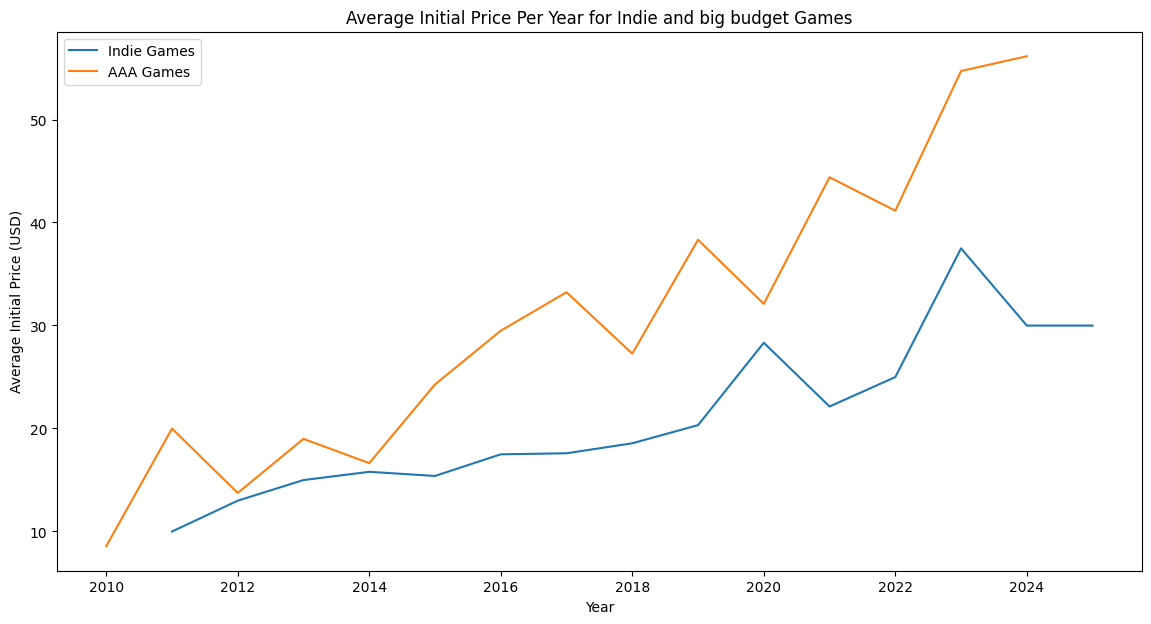

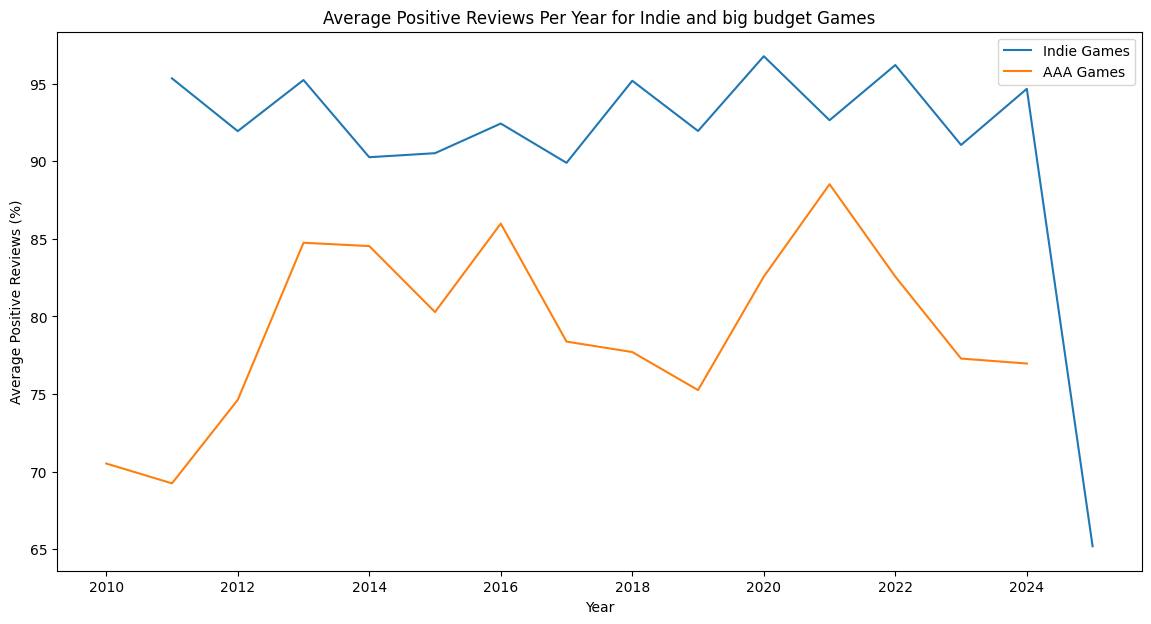

: 

In [ ]:

# Convert the lists of Series to DataFrames
indies_df = pandas.DataFrame(indies)
aaa_df = pandas.DataFrame(aaa)
indies_df = indies_df[indies_df['total_reviews'] > 1000]
aaa_df = aaa_df[aaa_df['total_reviews'] > 1000]


# Convert release_date to datetime
indies_df['release_date'] = pandas.to_datetime(indies_df['release_date'], errors='coerce')
aaa_df['release_date'] = pandas.to_datetime(aaa_df['release_date'], errors='coerce')

# Calculate the average initial price per year for indie and AAA games
indies_df['year'] = indies_df['release_date'].dt.year
aaa_df['year'] = aaa_df['release_date'].dt.year


indie_avg_price_per_year = indies_df.groupby('year')['price_initial (USD)'].mean()
aaa_avg_price_per_year = aaa_df.groupby('year')['price_initial (USD)'].mean()

indie_avg_price_per_year  = indie_avg_price_per_year[indie_avg_price_per_year.index >= 2010]
aaa_avg_price_per_year = aaa_avg_price_per_year[aaa_avg_price_per_year.index >= 2010]

indie_avg_price_per_year = indie_avg_price_per_year.dropna()
aaa_avg_price_per_year = aaa_avg_price_per_year.dropna()


# Plot average initial price per year for indie and AAA games
plt.figure(figsize=(14, 7))
plt.plot(indie_avg_price_per_year.index, indie_avg_price_per_year.values, label='Indie Games')
plt.plot(aaa_avg_price_per_year.index, aaa_avg_price_per_year.values, label='AAA Games')
plt.xlabel('Year')
plt.ylabel('Average Initial Price (USD)')
plt.title('Average Initial Price Per Year for Indie and big budget Games')
plt.legend()
plt.show()

# Agora calculando a media de porcentage de reviews positivas

indie_avg_posreviews_per_year = indies_df.groupby('year')['positive_percentual'].mean()
aaa_avg_posreviews_per_year = aaa_df.groupby('year')['positive_percentual'].mean()

indie_avg_posreviews_per_year = indie_avg_posreviews_per_year[indie_avg_posreviews_per_year.index >= 2010]

aaa_avg_posreviews_per_year = aaa_avg_posreviews_per_year[aaa_avg_posreviews_per_year.index >= 2010]

plt.figure(figsize=(14, 7))
plt.plot(indie_avg_posreviews_per_year.index, indie_avg_posreviews_per_year.values, label='Indie Games')
plt.plot(aaa_avg_posreviews_per_year.index, aaa_avg_posreviews_per_year.values, label='AAA Games')
plt.xlabel('Year')
plt.ylabel('Average Positive Reviews (%)')
plt.title('Average Positive Reviews Per Year for Indie and big budget Games')
plt.legend()
plt.show()
